# Notebook 04: Modality Analysis (Exp2)

Formal analysis of single-modality contribution and fusion gain from the modality removal experiments.

**Derived metrics**:
- **Dominance Index (DI)**: which modality carries more information per condition
- **Fusion Gain (FG)**: how much does having both modalities add over the better single stream
- **Fallback Efficiency (FE)**: how much of dual-modality performance survives when one stream fails

**Requires**: `analysis/data/exp1_df.parquet`, `analysis/data/exp2_df.parquet`

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

df_exp1 = pd.read_parquet(DATA_DIR / "exp1_df.parquet")
df_exp2 = pd.read_parquet(DATA_DIR / "exp2_df.parquet")
df_exp0 = pd.read_parquet(DATA_DIR / "exp0_df.parquet")

MODELS = ["early_fusion", "c2former", "ua_cmddet"]
MODEL_LABELS = {"early_fusion": "Early Fusion", "c2former": "C2Former", "ua_cmddet": "UA-CMDet"}
COLORS = {"early_fusion": "#1f77b4", "c2former": "#2ca02c", "ua_cmddet": "#d62728"}

print(f"exp1: {df_exp1.shape}")
print(f"exp2: {df_exp2.shape}")

exp1: (69, 7)
exp2: (146, 7)


## 1. Build Merged Dataset

Pivot exp2 to get `rgb_only_map` and `tir_only_map` per condition, then join with `dual_map` from exp1.

In [13]:
# Pivot exp2 to wide: one row per (model, modality, corruption, severity)
# columns: rgb_only_map, tir_only_map
exp2_pivot = df_exp2.pivot_table(
    index=["model", "modality", "corruption", "severity"],
    columns="config",
    values="map",
    aggfunc="first"
).reset_index()
exp2_pivot.columns.name = None
exp2_pivot = exp2_pivot.rename(columns={"rgb_only": "rgb_only_map", "tir_only": "tir_only_map"})

# Join with dual-modality map from exp1
exp1_dual = df_exp1[["model", "modality", "corruption", "severity", "map", "clean_map", "ra"]].copy()
exp1_dual = exp1_dual.rename(columns={"map": "dual_map"})

merged = exp2_pivot.merge(
    exp1_dual,
    on=["model", "modality", "corruption", "severity"],
    how="inner"
)

print(f"Merged dataset: {merged.shape}")
print(f"Expected: {len(exp2_pivot)} exp2 conditions paired with dual mAP")
print(f"Unmatched: {len(exp2_pivot) - len(merged)}")
merged.head()

Merged dataset: (69, 9)
Expected: 69 exp2 conditions paired with dual mAP
Unmatched: 0


,model,modality,corruption,severity,rgb_only_map,tir_only_map,dual_map,clean_map,ra
0,c2former,rgb,brightness_shift,1,0.430162,0.387539,0.685405,0.704573,0.972794
1,c2former,rgb,brightness_shift,2,0.407163,0.387539,0.654027,0.704573,0.928259
2,c2former,rgb,brightness_shift,3,0.356032,0.387539,0.622688,0.704573,0.883780
3,c2former,rgb,complete_dropout,sdropout,0.000000,0.387539,0.387539,0.704573,0.550034
4,c2former,rgb,gaussian_noise,1,0.326269,0.387539,0.652474,0.704573,0.926056


## 2. Compute Derived Modality Metrics

- **DI** = (tir_only − rgb_only) / max(tir_only, rgb_only + ε): positive = TIR-dominant
- **FG** = dual_map − max(rgb_only_map, tir_only_map): fusion adds this much over best single stream
- **FE** = max(rgb_only_map, tir_only_map) / dual_map: fraction of dual-modality perf recoverable

In [14]:
EPS = 1e-6

merged["best_single"] = merged[["rgb_only_map", "tir_only_map"]].max(axis=1)
merged["DI"] = (
    (merged["tir_only_map"] - merged["rgb_only_map"]) /
    (merged[["tir_only_map", "rgb_only_map"]].max(axis=1) + EPS)
)
merged["FG"] = merged["dual_map"] - merged["best_single"]
merged["FE"] = merged["best_single"] / (merged["dual_map"] + EPS)
merged["model_label"] = merged["model"].map(MODEL_LABELS)

print("=== Derived metric ranges ===")
for col in ["DI", "FG", "FE"]:
    print(f"{col}: min={merged[col].min():.4f}, max={merged[col].max():.4f}, mean={merged[col].mean():.4f}")

=== Derived metric ranges ===
DI: min=-1.0000, max=1.0000, mean=-0.1392
FG: min=-0.0637, max=0.2967, mean=0.1048
FE: min=0.4187, max=1.5104, mean=0.8273


## 3. Single-Modality Clean Baselines

Extract from exp2 complete_dropout conditions (one modality is corrupted away → other modality runs alone at full quality).

In [15]:
clean_rgb = df_exp2[
    (df_exp2["corruption"] == "complete_dropout") &
    (df_exp2["modality"] == "tir") &
    (df_exp2["config"] == "rgb_only")
][["model", "map"]].drop_duplicates(subset=["model"]).rename(columns={"map": "clean_rgb_only_map"})

clean_tir = df_exp2[
    (df_exp2["corruption"] == "complete_dropout") &
    (df_exp2["modality"] == "rgb") &
    (df_exp2["config"] == "tir_only")
][["model", "map"]].drop_duplicates(subset=["model"]).rename(columns={"map": "clean_tir_only_map"})

baselines = clean_rgb.merge(clean_tir, on="model")
baselines = baselines.merge(df_exp0[["model", "map"]].rename(columns={"map": "dual_clean_map"}), on="model")
baselines["rgb_pct_of_dual"] = baselines["clean_rgb_only_map"] / baselines["dual_clean_map"] * 100
baselines["tir_pct_of_dual"] = baselines["clean_tir_only_map"] / baselines["dual_clean_map"] * 100
baselines["model_label"] = baselines["model"].map(MODEL_LABELS)

print("=== Single-Modality Clean Baselines ===")
print(baselines.set_index("model_label")[["clean_rgb_only_map", "rgb_pct_of_dual", "clean_tir_only_map", "tir_pct_of_dual"]].round(4).to_string())

=== Single-Modality Clean Baselines ===
              clean_rgb_only_map  rgb_pct_of_dual  clean_tir_only_map  tir_pct_of_dual
model_label                                                                           
C2Former                  0.4339          61.5834              0.3875          55.0034
Early Fusion              0.1499          30.9100              0.2977          61.4030
UA-CMDet                  0.2105          98.5098              0.0019           0.8801


## 4. Dominance Index (DI) — Statistical Test

**H₀**: DI = 0 (no modality dominance) — test with Wilcoxon signed-rank (one-sample vs 0).

- EF expected: DI > 0 (TIR-dominant)
- UAC expected: DI << 0 (RGB-dominant)
- C2F expected: DI ≈ 0 (balanced)

In [16]:
di_results = []
for model in MODELS:
    di_vals = merged[merged["model"] == model]["DI"].dropna().values
    # Wilcoxon signed-rank test (one-sample vs 0)
    if (di_vals == 0).all():
        stat, pval = 0.0, 1.0
    else:
        stat, pval = stats.wilcoxon(di_vals, alternative="two-sided")
    median_di = np.median(di_vals)
    mean_di = np.mean(di_vals)
    di_results.append({
        "model": MODEL_LABELS[model],
        "n": len(di_vals),
        "mean_DI": mean_di,
        "median_DI": median_di,
        "W": stat,
        "p_value": pval,
        "dominant_modality": "TIR" if mean_di > 0 else "RGB",
        "significant": pval < 0.05,
    })

df_di = pd.DataFrame(di_results)
print("=== Dominance Index — Wilcoxon test vs H₀: DI=0 ===")
print(df_di.to_string())

=== Dominance Index — Wilcoxon test vs H₀: DI=0 ===
          model   n   mean_DI  median_DI      W       p_value dominant_modality  significant
0  Early Fusion  23  0.539360   0.571606   21.0  3.726165e-04               TIR         True
1      C2Former  23 -0.058585  -0.048195  118.0  5.599585e-01               RGB        False
2      UA-CMDet  23 -0.898518  -0.989664    2.0  7.152557e-07               RGB         True


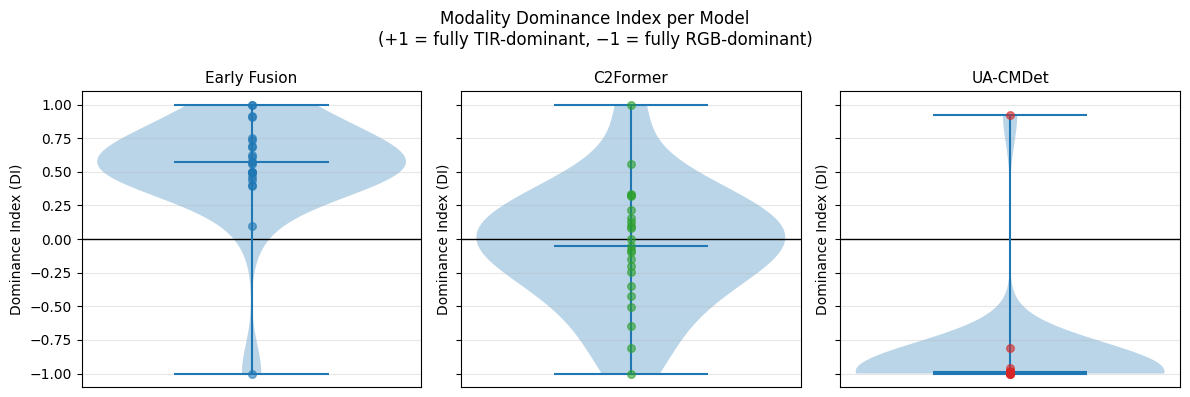

Saved: nb04_dominance_index.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, model in enumerate(MODELS):
    ax = axes[i]
    di_vals = merged[merged["model"] == model]["DI"].dropna().values
    ax.axhline(0, color="black", linewidth=1)
    ax.violinplot(di_vals, positions=[0], showmedians=True)
    ax.scatter([0] * len(di_vals), di_vals, color=COLORS[model], alpha=0.6, s=30, zorder=3)
    ax.set_title(MODEL_LABELS[model], fontsize=11)
    ax.set_xticks([])
    ax.set_ylabel("Dominance Index (DI)", fontsize=10)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Modality Dominance Index per Model\n(+1 = fully TIR-dominant, −1 = fully RGB-dominant)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "nb04_dominance_index.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb04_dominance_index.png")

## 5. Fusion Gain — Does Dual-Modality Add Value?

For each condition: how much mAP does having both modalities add over the single best stream?

In [18]:
print("=== Fusion Gain (FG = dual_map - max(rgb_only, tir_only)) ===")
fg_summary = (
    merged.groupby("model")["FG"]
    .agg(mean="mean", std="std", median="median", min_fg="min", max_fg="max")
    .rename(index=MODEL_LABELS)
)
print(fg_summary.round(4).to_string())

print("\n=== Fusion Gain < 0 (dual WORSE than best single stream — degraded fusion) ===")
neg_fg = merged[merged["FG"] < 0][["model_label", "modality", "corruption", "severity", "dual_map", "best_single", "FG"]]
if len(neg_fg) > 0:
    print(neg_fg.sort_values("FG").to_string())
else:
    print("None — dual-modality always >= best single stream")

=== Fusion Gain (FG = dual_map - max(rgb_only, tir_only)) ===
                mean     std  median  min_fg  max_fg
model                                               
C2Former      0.2026  0.0787  0.2253  0.0000  0.2967
Early Fusion  0.1145  0.0821  0.1332 -0.0637  0.2309
UA-CMDet     -0.0026  0.0090  0.0010 -0.0306  0.0064

=== Fusion Gain < 0 (dual WORSE than best single stream — degraded fusion) ===
     model_label modality        corruption  severity  dual_map  best_single        FG
32  Early Fusion      rgb      low_contrast         3  0.234043     0.297749 -0.063706
68      UA-CMDet      tir      sensor_noise         3  0.179888     0.210484 -0.030596
67      UA-CMDet      tir      sensor_noise         2  0.192008     0.210484 -0.018476
31  Early Fusion      rgb      low_contrast         2  0.281790     0.297749 -0.015959
50      UA-CMDet      rgb    gaussian_noise         1  0.091234     0.106285 -0.015052
66      UA-CMDet      tir      sensor_noise         1  0.198104     0.2

## 6. Fallback Efficiency Under Severe Corruption

When a stream is severely corrupted (S3), how much of dual-modality performance does the clean stream preserve?

In [19]:
# S3 conditions only
s3 = merged[merged["severity"] == "3"].copy()

# For RGB corruptions: TIR fallback efficiency = tir_only_map / dual_clean_map
# For TIR corruptions: RGB fallback efficiency = rgb_only_map / dual_clean_map
baselines_dict = baselines.set_index("model")["dual_clean_map"].to_dict()

rgb_corruptions = ["gaussian_noise", "motion_blur", "brightness_shift", "low_contrast"]
tir_corruptions = ["sensor_noise", "blur", "intensity_shift"]

s3["dual_clean"] = s3["model"].map(baselines_dict)

print("=== TIR fallback (tir_only_map) under S3 RGB corruption ===")
print("(how well TIR alone recovers when RGB is severely degraded)")
rgb_s3 = s3[s3["corruption"].isin(rgb_corruptions)]
print(rgb_s3.pivot_table(
    index="corruption", columns="model_label",
    values="tir_only_map", aggfunc="first"
).round(4).to_string())

print("\n=== RGB fallback (rgb_only_map) under S3 TIR corruption ===")
tir_s3 = s3[s3["corruption"].isin(tir_corruptions)]
print(tir_s3.pivot_table(
    index="corruption", columns="model_label",
    values="rgb_only_map", aggfunc="first"
).round(4).to_string())

=== TIR fallback (tir_only_map) under S3 RGB corruption ===
(how well TIR alone recovers when RGB is severely degraded)
model_label       C2Former  Early Fusion  UA-CMDet
corruption                                        
brightness_shift    0.3875        0.2977    0.0019
gaussian_noise      0.3875        0.2977    0.0019
low_contrast        0.3875        0.2977    0.0019
motion_blur         0.3875        0.2977    0.0019

=== RGB fallback (rgb_only_map) under S3 TIR corruption ===
model_label      C2Former  Early Fusion  UA-CMDet
corruption                                       
blur               0.4339        0.1499    0.2105
intensity_shift    0.4339        0.1499    0.2105
sensor_noise       0.4339        0.1499    0.2105


## 7. Spearman ρ: Dual RA vs Fallback Efficiency

Does better fallback efficiency predict better dual-modality robustness? If yes, a model with a stronger single-stream fallback also degrades less in dual-modality operation.

In [20]:
print("=== Spearman ρ: exp1 dual RA vs Fallback Efficiency (FE) ===")
for model in MODELS:
    subset = merged[merged["model"] == model].dropna(subset=["ra", "FE"])
    if len(subset) < 5:
        print(f"{MODEL_LABELS[model]}: too few rows")
        continue
    rho, pval = stats.spearmanr(subset["ra"].values, subset["FE"].values)
    print(f"{MODEL_LABELS[model]:15s}: ρ={rho:.4f}, p={pval:.4f}, n={len(subset)}")
print("\nInterpretation: positive ρ = better fallback → better dual RA (compensatory fusion works)")

=== Spearman ρ: exp1 dual RA vs Fallback Efficiency (FE) ===
Early Fusion   : ρ=-0.8162, p=0.0000, n=23
C2Former       : ρ=-0.7223, p=0.0001, n=23
UA-CMDet       : ρ=-0.6433, p=0.0009, n=23

Interpretation: positive ρ = better fallback → better dual RA (compensatory fusion works)


## 8. C2Former RGB vs TIR Degradation Asymmetry

For C2Former (the balanced model), test whether corrupting RGB or corrupting TIR causes more severe degradation in single-modality operation.

In [21]:
c2f = merged[(merged["model"] == "c2former") & (merged["severity"].isin(["1", "2", "3"]))].copy()

# When RGB is corrupted: how does rgb_only_map degrade relative to clean RGB baseline?
clean_rgb_c2f = baselines.loc[baselines["model"] == "c2former", "clean_rgb_only_map"].values[0]
clean_tir_c2f = baselines.loc[baselines["model"] == "c2former", "clean_tir_only_map"].values[0]

rgb_corr_c2f = c2f[c2f["modality"] == "rgb"].copy()
rgb_corr_c2f["rgb_single_ra"] = rgb_corr_c2f["rgb_only_map"] / (clean_rgb_c2f + 1e-6)

tir_corr_c2f = c2f[c2f["modality"] == "tir"].copy()
tir_corr_c2f["tir_single_ra"] = tir_corr_c2f["tir_only_map"] / (clean_tir_c2f + 1e-6)

print("=== C2Former: Mean single-modality RA under own-stream corruption ===")
print(f"RGB corruptions → rgb_only_ra: mean={rgb_corr_c2f['rgb_single_ra'].mean():.4f}, std={rgb_corr_c2f['rgb_single_ra'].std():.4f}")
print(f"TIR corruptions → tir_only_ra: mean={tir_corr_c2f['tir_single_ra'].mean():.4f}, std={tir_corr_c2f['tir_single_ra'].std():.4f}")

# Wilcoxon test: are these distributions different?
if len(rgb_corr_c2f) == len(tir_corr_c2f):
    w_stat, p_asym = stats.wilcoxon(rgb_corr_c2f["rgb_single_ra"].values, tir_corr_c2f["tir_single_ra"].values)
    print(f"\nWilcoxon paired test (same severity levels): W={w_stat:.2f}, p={p_asym:.4f}")
else:
    u_stat, p_asym = stats.mannwhitneyu(rgb_corr_c2f["rgb_single_ra"].values, tir_corr_c2f["tir_single_ra"].values, alternative="two-sided")
    print(f"\nMann-Whitney U (unpaired): U={u_stat:.2f}, p={p_asym:.4f}")

=== C2Former: Mean single-modality RA under own-stream corruption ===
RGB corruptions → rgb_only_ra: mean=0.7401, std=0.1708
TIR corruptions → tir_only_ra: mean=0.6946, std=0.2709

Mann-Whitney U (unpaired): U=55.00, p=0.9717


In [22]:
from io import StringIO
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
buf = StringIO()

buf.write("=== NB04 MODALITY ANALYSIS ===\n\n")

buf.write("--- Single-modality clean baselines ---\n")
buf.write(baselines.set_index("model_label")[
    ["clean_rgb_only_map", "rgb_pct_of_dual", "clean_tir_only_map", "tir_pct_of_dual"]
].round(4).to_string() + "\n\n")

buf.write("--- Dominance Index test (Wilcoxon vs 0) ---\n")
buf.write(df_di.round(4).to_string() + "\n\n")

buf.write("--- Fusion Gain per model ---\n")
buf.write(merged.groupby("model_label")["FG"].agg(
    mean="mean", std="std", median="median", min_fg="min", max_fg="max"
).round(4).to_string() + "\n\n")

buf.write("--- TIR fallback under S3 RGB corruption ---\n")
rgb_s3 = merged[(merged["corruption"].isin(["gaussian_noise","motion_blur","brightness_shift","low_contrast"])) & (merged["severity"]=="3")]
buf.write(rgb_s3.pivot_table(index="corruption", columns="model_label", values="tir_only_map", aggfunc="first").round(4).to_string() + "\n\n")

buf.write("--- RGB fallback under S3 TIR corruption ---\n")
tir_s3 = merged[(merged["corruption"].isin(["sensor_noise","blur","intensity_shift"])) & (merged["severity"]=="3")]
buf.write(tir_s3.pivot_table(index="corruption", columns="model_label", values="rgb_only_map", aggfunc="first").round(4).to_string() + "\n\n")

buf.write("--- Spearman rho: dual RA vs fallback efficiency ---\n")
for model in ["early_fusion", "c2former", "ua_cmddet"]:
    subset = merged[merged["model"] == model].dropna(subset=["ra", "FE"])
    if len(subset) >= 5:
        rho, pval = __import__("scipy").stats.spearmanr(subset["ra"].values, subset["FE"].values)
        buf.write(f"{model}: rho={rho:.4f}  p={pval:.4f}  n={len(subset)}\n")

out_path = OUTPUT_DIR / "nb04_results.txt"
out_path.write_text(buf.getvalue())
print(f"Results written to {out_path.resolve()}")

Results written to C:\Users\saksh\Desktop\Thesis\drone-multimodal-robustness\analysis\outputs\nb04_results.txt


## Summary

Key results to carry into thesis RQ2 section:

1. **DI per model** (mean + Wilcoxon p): confirms EF TIR-dominance and UAC RGB-collapse quantitatively
2. **Fusion Gain per model**: shows whether cross-attention genuinely adds information vs. just selecting the better stream
3. **Fallback Efficiency table (S3)**: the quantitative foundation for the fault-tolerance analysis
4. **C2Former asymmetry test**: confirms whether RGB or TIR is more vulnerable to corruption in the balanced architecture

Proceed to `nb_05_figures_publication.ipynb`.